In [ ]:
# %%

# ----------- this file provides the reproducible training and plots in the paper ------------#
# 0. load libraries
import os
os.chdir("/hpc/home/yx306/DRE")
os.getcwd()

data_path = "/hpc/group/mastatlab/yx306/MNIST/"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import utils.help_func as help
import torch
import utils.DRE_func as dre
import utils.DRE_batch as dre_batch
from matplotlib.colors import TwoSlopeNorm
from importlib import reload
import utils.MNIST_help as mnist

SEED = 42
# Python built-in RNG
def set_seed(seed=42):
    import random, numpy as np, torch
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"[Seed set to {seed}]")

# Make cuDNN deterministic (may slightly slow training)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# to load MNIST data
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
from pathlib import Path

ROOT = Path(data_path)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# %%

# ----------- this file provides the reproducible training and plots in the paper ------------#
# 0. load libraries
import os
os.chdir("/hpc/home/yx306/DRE")
os.getcwd()

data_path = "/hpc/group/mastatlab/yx306/MNIST/"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import utils.help_func as help
import torch
import utils.DRE_func as dre
import utils.DRE_batch as dre_batch
from matplotlib.colors import TwoSlopeNorm
from importlib import reload
import utils.MNIST_help as mnist

SEED = 42
# Python built-in RNG
def set_seed(seed=42):
    import random, numpy as np, torch
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"[Seed set to {seed}]")

# Make cuDNN deterministic (may slightly slow training)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# to load MNIST data
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
from pathlib import Path

ROOT = Path(data_path)
device = "cuda" if torch.cuda.is_available() else "cpu"

[Seed set to 42]
epoch 000 step 000000  loss 0.0080  ema 0.0080  lr 6.00e-05
epoch 000 step 000100  loss -0.0188  ema -0.0077  lr 2.74e-04
[val] epoch 000  val_loss -0.0212
[val] epoch 000  val_loss -0.0212
epoch 001 step 000200  loss -0.0234  ema -0.0199  lr 5.75e-04
[val] epoch 001  val_loss -0.0278
[val] epoch 001  val_loss -0.0278
epoch 002 step 000300  loss -0.0297  ema -0.0316  lr 5.98e-04
[val] epoch 002  val_loss -0.0085
[val] epoch 002  val_loss -0.0085
epoch 003 step 000400  loss -0.0485  ema -0.0435  lr 5.91e-04
[val] epoch 003  val_loss -0.0195
[val] epoch 003  val_loss -0.0195
epoch 004 step 000500  loss -0.0587  ema -0.0528  lr 5.76e-04
[val] epoch 004  val_loss -0.0469
[val] epoch 004  val_loss -0.0469
epoch 005 step 000600  loss -0.0508  ema -0.0483  lr 5.56e-04
epoch 005 step 000700  loss -0.0559  ema -0.0531  lr 5.30e-04
[val] epoch 005  val_loss -0.0683
[val] epoch 005  val_loss -0.0683
epoch 006 step 000800  loss -0.0690  ema -0.0660  lr 4.99e-04
[val] epoch 006  va

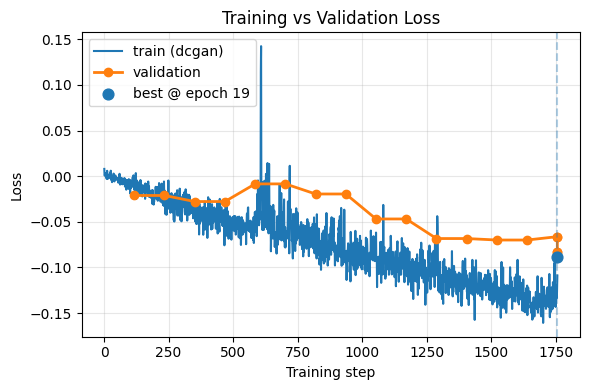

In [ ]:
# %%

# try batch DRE on DCGAN
# real data loader for q (can be separate from p_loader to avoid overlap)
reload(dre)
reload(dre_batch)
set_seed(SEED)

transform = transforms.Compose([
    transforms.ToTensor(),                # [0,1]
    transforms.Lambda(lambda t: t*2.0 - 1.0),  # match generator scaling if needed
])


# set batch size:
batch_size = 512

mnist_train = datasets.MNIST(root=ROOT, train=True, download=False, 
                transform=transform)
p_loader = DataLoader(mnist_train, batch_size=batch_size,
                 shuffle=True, num_workers=2, drop_last=True)

mnist_val = datasets.MNIST(root=ROOT, train=False, download=False, transform=transform)
val_loader = DataLoader(mnist_val, batch_size=batch_size, shuffle=False, num_workers=2, drop_last=False)

# Sampler: 50% generator, 50% real
G, nz = mnist.build_dcgan28(data_path+"mnist_dcgan/netG_epoch_99.pth", device=device)
q_sampler = dre_batch.make_q_mixed_sampler(G, nz, p_loader, gen_frac=0.5, post=None)

num_epochs_planned = 20
# 3) Train
model, losses, val_losses = dre_batch.run_DRE_fdiv_cnn_minibatch(
    p_loader=p_loader,
    q_sampler=q_sampler,
    num_epochs=num_epochs_planned,
    print_every=100,
    bn_freeze_epoch=5,
    val_loader=val_loader,   # <--- enable validation
    val_q_batches=8,
    early_stop_patience = 5  
)

# plot loss
reload(help)
fig, ax = plt.subplots(figsize=(6,4))
# 1) training (per-step)
help.plot_losses(losses, label="train (dcgan)", ax=ax, color="tab:blue")

# 2) validation (per-epoch, align to end-of-epoch step)
steps_per_epoch = len(p_loader)                 # constant because drop_last=True
epochs_run = len(val_losses)

if epochs_run > 0:
    if len(val_losses) > num_epochs_planned:
        val_losses = val_losses[:num_epochs_planned]

        epochs_run = len(val_losses)
        if epochs_run == 0:
            print("No validation losses recorded.")
        else:
            steps_per_epoch = len(p_loader)  # drop_last=True so this is constant

            # end-of-epoch step positions: 1*spe, 2*spe, ..., epochs_run*spe
            val_steps = steps_per_epoch * np.arange(1, epochs_run + 1)

            # clip to the last available training step (in case of tiny rounding mismatches)
            val_steps = np.minimum(val_steps, len(losses))

            # plot
            ax.plot(val_steps, val_losses, 'o-', label="validation", color="tab:orange", linewidth=2)

            # best epoch (1-based for readability)
            best_idx = int(np.argmin(val_losses))        # 0-based index
            best_epoch = best_idx + 1                    # 1-based label
            best_step = int(val_steps[best_idx])
            best_val = float(val_losses[best_idx])

            ax.axvline(best_step, linestyle="--", alpha=0.35)
            ax.scatter([best_step], [best_val], s=60, zorder=5, label=f"best @ epoch {best_epoch}")
            print(f"Best epoch = {best_epoch} | step ≈ {best_step} | val_loss = {best_val:.4f}")
else:
    print("No validation losses recorded.")

ax.set_title("Training vs Validation Loss")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

        g_p_dcgan  g_mixed_dcgan  g_q_dcgan
length   10000.00       20000.00   10000.00
mean         1.18           0.90       0.63
std          0.54           0.60       0.52
min          0.01           0.00       0.00
q1           0.75           0.35       0.18
median       1.26           0.87       0.49
q3           1.65           1.43       0.99
max          2.00           2.00       1.99


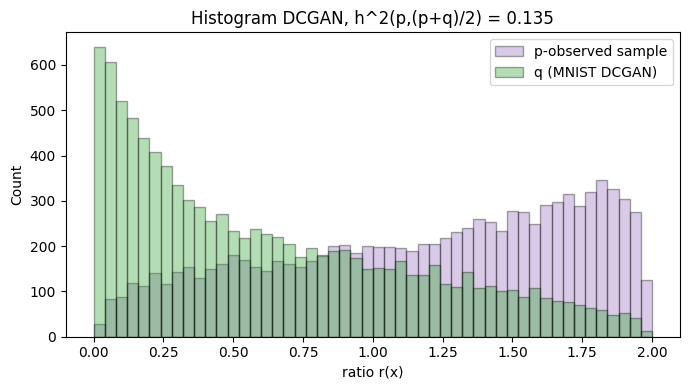

In [ ]:
# %%

# evaluate dcgan
reload(dre)

n_eval = 10000
real = mnist.get_mnist_real_sampler(root=ROOT, 
            split="test", device=device, flatten=True)
x_p, y_p = real(n=n_eval, seed=0, return_labels=True)   # x_p: (5000, 784) in [0,1]


fake = mnist.get_generator_sampler(
    generator=G, z_dim=nz, device=device,
    z_type="noise_4d",
    generator_output_range="[-1,1]",  # DCGAN tanh
    return_range="[0,1]",             # DRE expects [0,1]
    out_size=(28,28), flatten=True, channels=1
)
x_q = fake(n=n_eval, seed=1)  

x_mixed = torch.cat([x_p, x_q], dim=0) 
g_p, g_q, g_mixed = dre.evaluate_model(model, x_p, x_q, x_mixed)

# check summary stats
stats = {
    "g_p_dcgan": help.summarize_vector(g_p.detach().cpu().numpy()),
    "g_mixed_dcgan": help.summarize_vector(g_mixed.detach().cpu().numpy()),
    "g_q_dcgan": help.summarize_vector(g_q.detach().cpu().numpy()),
}

df = pd.DataFrame(stats)
print(df.round(2))  # show 4 digits



# plot hist
bool_density = False
ax, bin_edges = help.plot_ratio_hist(g_p.detach().cpu().numpy(), 
                                     bins=50, range=(0,2), density=bool_density,
                                     label="p-observed sample", color="tab:purple")
help.add_ratio_hist(g_q.detach().cpu().numpy(), ax=ax, bin_edges=bin_edges, 
                    density=bool_density,
                    label="q (MNIST DCGAN)", color="tab:green")
ax.legend(); 
steps_per_epoch = len(p_loader)
last_epoch = losses[-steps_per_epoch:]
mean_last_epoch = float(np.mean(last_epoch))
ax.set_title(f"Histogram DCGAN, h^2(p,(p+q)/2) = {-mean_last_epoch:.3f}")
plt.tight_layout(); plt.show()# %%

[Seed set to 42]
epoch 000 step 000000  loss 0.0000  ema 0.0000  lr 6.11e-05
epoch 000 step 000100  loss -0.2318  ema -0.1887  lr 5.36e-04
[val] epoch 000  val_loss -0.2430
[val] epoch 000  val_loss -0.2430
epoch 001 step 000200  loss -0.2791  ema -0.2684  lr 2.73e-04
[val] epoch 001  val_loss -0.2758
[val] epoch 001  val_loss -0.2758
epoch 002 step 000300  loss -0.2720  ema -0.2770  lr 3.50e-05
[val] epoch 002  val_loss -0.2772
[val] epoch 002  val_loss -0.2772
Best epoch = 3 | step ≈ 351 | val_loss = -0.2758


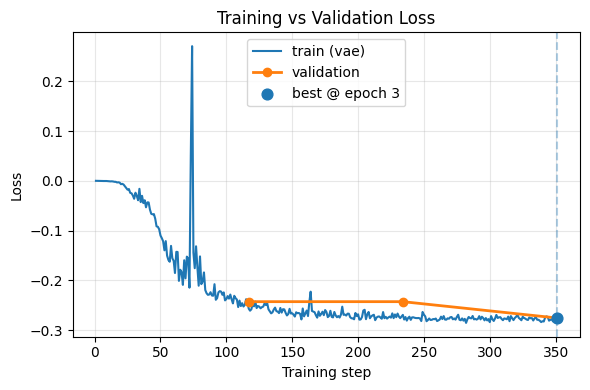

In [ ]:
# %%

# try batch DRE on VAE
reload(dre_batch)
set_seed(SEED)

vae_weight = data_path + "mnist_vae/vae_epoch_25.pth"
from twoD_MNIST.vae import VAE
reload(mnist)
vae = mnist.VAEWrapper.from_repo(
    weights=vae_weight,   # <-- adjust filename if it differs
    module_path="twoD_MNIST",              # folder in the repo
    class_name="VAE",                     # adjust if the class has a different name
    # model_ctor=lambda: MyVAE(latent_dim=20),  # optional custom constructor
    latent_dim=20,                                # only if inference fails
)

q_mixed_vae_sampler = dre_batch.make_mnist_vae_50_50_sampler(
    vae,
    real_loader=p_loader,
    post=lambda t: t*2.0 - 1.0,   # map VAE's [0,1] -> [-1,1]
    return_source=False
)

num_epochs_planned = 3
# 3) Train
model_vae, losses_vae, val_losses_vae= dre_batch.run_DRE_fdiv_cnn_minibatch(
    p_loader=p_loader,
    q_sampler=q_mixed_vae_sampler,
    num_epochs=num_epochs_planned,
    print_every=100,
    bn_freeze_epoch=0,
    val_loader=val_loader,   # <--- enable validation
    val_q_batches=8,
    early_stop_patience = 5    
)

# plot loss
reload(help)
fig, ax = plt.subplots(figsize=(6,4))
help.plot_losses(losses_vae, label="train (vae)", ax=ax, color="tab:blue")

# 2) validation (per-epoch, align to end-of-epoch step)
steps_per_epoch = len(p_loader)                 # constant because drop_last=True
epochs_run = len(val_losses_vae)

if epochs_run > 0:
    if len(val_losses_vae) > num_epochs_planned:
        val_losses_vae = val_losses_vae[:num_epochs_planned]

        epochs_run = len(val_losses_vae)
        if epochs_run == 0:
            print("No validation losses recorded.")
        else:
            steps_per_epoch = len(p_loader)  # drop_last=True so this is constant

            # end-of-epoch step positions: 1*spe, 2*spe, ..., epochs_run*spe
            val_steps = steps_per_epoch * np.arange(1, epochs_run + 1)

            # clip to the last available training step (in case of tiny rounding mismatches)
            val_steps = np.minimum(val_steps, len(losses_vae))

            # plot
            ax.plot(val_steps, val_losses_vae, 'o-', label="validation", color="tab:orange", linewidth=2)

            # best epoch (1-based for readability)
            best_idx = int(np.argmin(val_losses_vae))        # 0-based index
            best_epoch = best_idx + 1                    # 1-based label
            best_step = int(val_steps[best_idx])
            best_val = float(val_losses_vae[best_idx])

            ax.axvline(best_step, linestyle="--", alpha=0.35)
            ax.scatter([best_step], [best_val], s=60, zorder=5, label=f"best @ epoch {best_epoch}")
            print(f"Best epoch = {best_epoch} | step ≈ {best_step} | val_loss = {best_val:.4f}")
else:
    print("No validation losses recorded.")

ax.set_title("Training vs Validation Loss")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()# %%

In [ ]:
# %%

# evaluate VAE and compare with DCGAN
reload(dre)
reload(dre_batch)

n_eval = 10000
real = mnist.get_mnist_real_sampler(root=ROOT, 
            split="test", device=device, flatten=True)
x_p_vae, y_p_vae = real(n=n_eval, seed=0, return_labels=True)   # x_p: (5000, 784) in [0,1]



x_q_vae = vae.generate(n=n_eval)
x_q_vae = x_q_vae * 2.0 - 1.0
x_q_vae = x_q_vae.view(n_eval, -1)

x_vae_mixed = torch.cat([x_p, x_q_vae], dim=0) 
g_p_vae, g_q_vae, g_mixed_vae = dre.evaluate_model(model_vae, x_p, x_q_vae, x_vae_mixed)
# g_p_vae, g_q_vae, g_mixed_vae = dre_batch.eval_vae_case(
#     model_vae, x_p, vae, n_eval
# )

stats = {
    "g_p_dcgan": help.summarize_vector(g_p.detach().cpu().numpy()),
    "g_mixed_dcgan": help.summarize_vector(g_mixed.detach().cpu().numpy()),
    "g_q_dcgan": help.summarize_vector(g_q.detach().cpu().numpy()),
}
df = pd.DataFrame(stats)
print(df.round(2))  # show 4 digits

stats = {
    "g_p_vae": help.summarize_vector(g_p_vae.detach().cpu().numpy()),
    "g_mixed_vae": help.summarize_vector(g_mixed_vae.detach().cpu().numpy()),
    "g_q_vae": help.summarize_vector(g_q_vae.detach().cpu().numpy()),
}
df = pd.DataFrame(stats)
print(df.round(2))  # show 4 digits

        g_p_dcgan  g_mixed_dcgan  g_q_dcgan
length   10000.00       20000.00   10000.00
mean         1.18           0.90       0.63
std          0.54           0.60       0.52
min          0.01           0.00       0.00
q1           0.75           0.35       0.18
median       1.26           0.87       0.49
q3           1.65           1.43       0.99
max          2.00           2.00       1.99
        g_p_vae  g_mixed_vae   g_q_vae
length  10000.0     20000.00  10000.00
mean        2.0         1.01      0.02
std         0.0         0.99      0.13
min         2.0         0.00      0.00
q1          2.0         0.00      0.00
median      2.0         1.97      0.00
q3          2.0         2.00      0.00
max         2.0         2.00      1.95


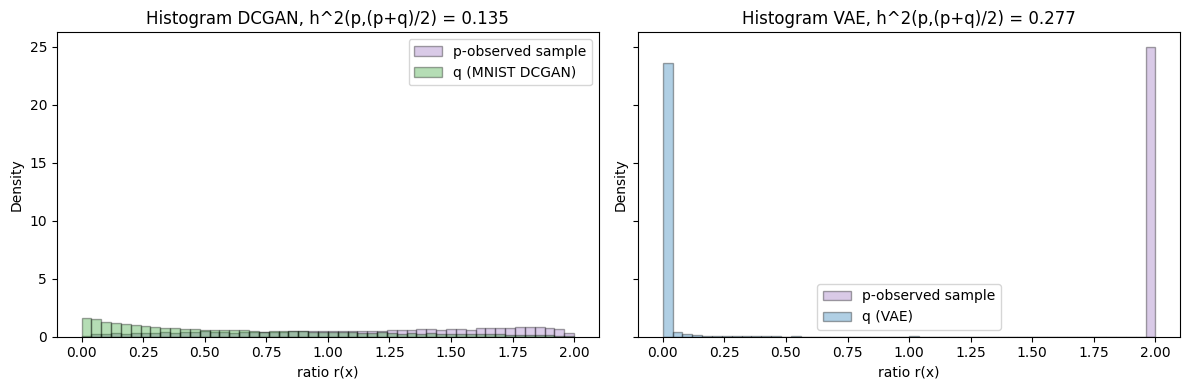

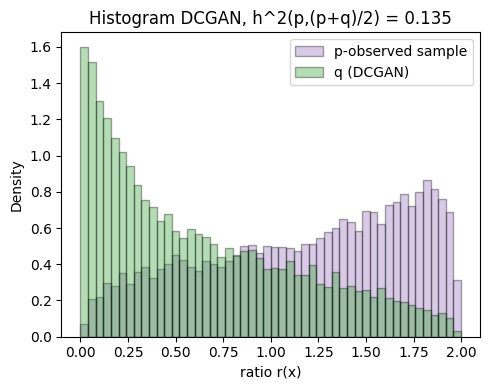

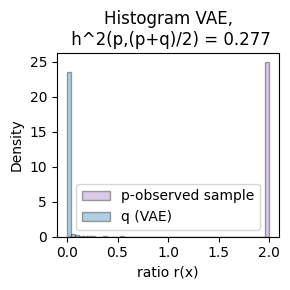

In [ ]:
# %%

# check histogram
reload(help)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
# Left plot: g_p vs g_q
bool_density = True
ax, bin_edges = help.plot_ratio_hist(g_p.detach().cpu().numpy(), 
                                     bins=50, range=(0,2), density=bool_density,
                                     label="p-observed sample", color="tab:purple",
                                     ax=axes[0])
help.add_ratio_hist(g_q.detach().cpu().numpy(), ax=ax, bin_edges=bin_edges, 
                    density=bool_density,
                    label="q (MNIST DCGAN)", color="tab:green")
ax.legend(); 
steps_per_epoch = len(p_loader)
last_epoch = losses[-steps_per_epoch:]
mean_last_epoch = float(np.mean(last_epoch))
ax.set_title(f"Histogram DCGAN, h^2(p,(p+q)/2) = {-mean_last_epoch:.3f}")

# # Right plot: g_p vs g_mixed
ax, bin_edges2 = help.plot_ratio_hist(g_p_vae.detach().cpu().numpy(), bins=50, 
                                     range=(0,2), density=bool_density,
                                      label="p-observed sample", color="tab:purple",
                                      ax=axes[1])
help.add_ratio_hist(g_q_vae.detach().cpu().numpy(), ax=ax, 
                    bin_edges=bin_edges2, density=bool_density,
                    label="q (VAE)", color="tab:blue")
ax.legend(); 
steps_per_epoch = len(p_loader)
last_epoch = losses_vae[-steps_per_epoch:]
mean_last_epoch = float(np.mean(last_epoch))
ax.set_title(f"Histogram VAE, h^2(p,(p+q)/2) = {-mean_last_epoch:.3f}")

plt.tight_layout(); plt.show()# %%

# DCGAN

bool_density = True
ax, bin_edges = help.plot_ratio_hist(g_p.detach().cpu().numpy(), 
                                     bins=50, range=(0,2), density=bool_density,
                                     label="p-observed sample", color="tab:purple",
                                    figsize=(5,4)
                                     )
help.add_ratio_hist(g_q.detach().cpu().numpy(), ax=ax, bin_edges=bin_edges, 
                    density=bool_density,
                    label="q (DCGAN)", color="tab:green")
ax.legend(); 
steps_per_epoch = len(p_loader)
last_epoch = losses[-steps_per_epoch:]
mean_last_epoch = float(np.mean(last_epoch))
ax.set_title(f"Histogram DCGAN, h^2(p,(p+q)/2) = {-mean_last_epoch:.3f}")

# vae
ax, bin_edges2 = help.plot_ratio_hist(g_p_vae.detach().cpu().numpy(), bins=50, 
                                     range=(0,2), density=bool_density,
                                      label="p-observed sample", color="tab:purple",
                                      figsize=(3,3)
                                      )
help.add_ratio_hist(g_q_vae.detach().cpu().numpy(), ax=ax, 
                    bin_edges=bin_edges2, density=bool_density,
                    label="q (VAE)", color="tab:blue")
ax.legend(); 
steps_per_epoch = len(p_loader)
last_epoch = losses_vae[-steps_per_epoch:]
mean_last_epoch = float(np.mean(last_epoch))
ax.set_title(f"Histogram VAE,\n h^2(p,(p+q)/2) = {-mean_last_epoch:.3f}")

plt.tight_layout(); plt.show()# %%

/hpc/home/yx306/DRE/utils/MNIST_help.py:236: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


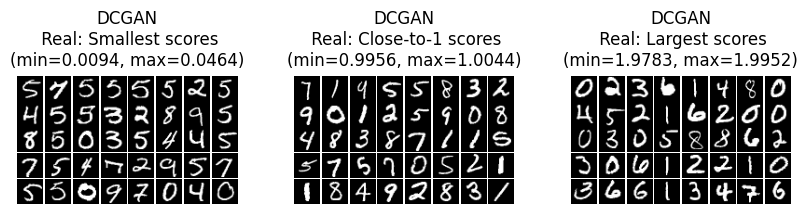

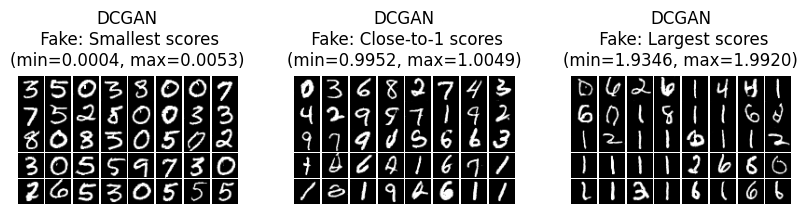

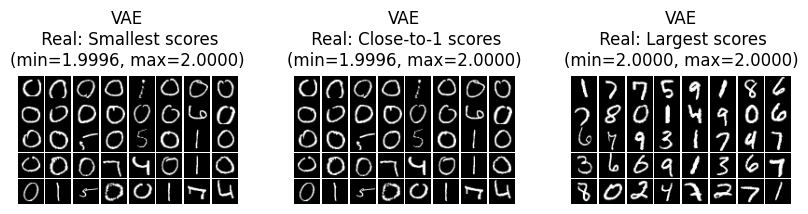

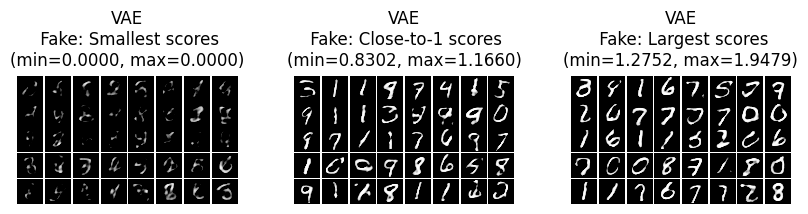

In [ ]:
# %%

# visualize samples
reload(mnist)
g_q_vae_flat = g_q_vae.view(-1)
g_q_flat = g_q.view(-1)
g_p_vae_flat = g_p_vae.view(-1)
g_p_flat = g_p.view(-1)

ncol = 8
nrow = 5
top_k = ncol*nrow
vae_p_extreme = mnist.find_extreme_indices(g_p_vae, top_k=top_k) # [0] value, [1] index
vae_q_extreme = mnist.find_extreme_indices(g_q_vae, top_k=top_k) # [0] value, [1] index


dcgan_p_extreme = mnist.find_extreme_indices(g_p, top_k=top_k) # [0] value, [1] index
dcgan_q_extreme = mnist.find_extreme_indices(g_q, top_k=top_k) # [0] value, [1] index


# fig, axes = plt.subplots(2, 2, figsize=(20, 10))  # 2 rows, 3 columns


mnist.plot_extremes_three_panels(
    x_p,
    dcgan_p_extreme,
    img_hw=28,
    ncols=(ncol, ncol, ncol),                 # choose columns per panel (left, middle, right)
    figsize=(10, nrow/3),
    cmap="gray",                     # change to None/RGB if your data are color
    vmin= 0, vmax=1.0,              # adjust if your images are in [-1,1], etc.
    super_title_prefix="DCGAN\n Real",   # matches your example figure text
    # ax = axes[1,0],
)

mnist.plot_extremes_three_panels(
    x_q,
    dcgan_q_extreme,
    img_hw=28,
    ncols=(ncol, ncol, ncol),                 # choose columns per panel (left, middle, right)
    figsize=(10, nrow/3),
    cmap="gray",                     # change to None/RGB if your data are color
    vmin= 0, vmax=1.0,              # adjust if your images are in [-1,1], etc.
    super_title_prefix="DCGAN\n Fake",   # matches your example figure text
    # ax = axes[1,1],
)

reload(mnist)
mnist.plot_extremes_three_panels(
    x_p_vae,
    vae_p_extreme,
    img_hw=28,
    ncols=(ncol, ncol, ncol),                 # choose columns per panel (left, middle, right)
    figsize=(10, nrow/3),
    cmap="gray",                     # change to None/RGB if your data are color
    vmin= 0, vmax=1.0,              # adjust if your images are in [-1,1], etc.
    super_title_prefix="VAE\n Real",   # matches your example figure text
    # ax = axes[0,0],
)

mnist.plot_extremes_three_panels(
    x_q_vae,
    vae_q_extreme,
    img_hw=28,
    ncols=(ncol, ncol, ncol),                 # choose columns per panel (left, middle, right)
    figsize=(10, nrow/3),
    cmap="gray",                     # change to None/RGB if your data are color
    vmin= 0, vmax=1.0,              # adjust if your images are in [-1,1], etc.
    super_title_prefix="VAE\n Fake",   # matches your example figure text
    # ax = axes[0,1]
)

In [ ]:
# %%

# summarize by category
reload(help)
# DCGAN
import seaborn as sns
sns.violinplot(
    x=y_p.cpu().numpy(),
    y=g_p.cpu().numpy(),
    inner="quartile",
    cut=0,            # do not extend beyond the observed min/max
    bw_adjust=0.8,   # (optional) slightly narrower bandwidth to reduce edge bleed
)
plt.ylim(0, 2)        # (optional) hard clip the axes as well
plt.xlabel("Digits")
plt.ylabel("r(x)")
plt.title("DCGAN: Distribution of r(X_p) by digits")
plt.show()



# VAE
sns.violinplot(x=y_p_vae.cpu(), y=g_p_vae.cpu(), inner="quartile")
plt.xlabel("Digits")
plt.ylabel("r(x)")
plt.title("VAE:Distribution of VAE r(X_p) by digits")
g_vals = g_p_vae.detach().cpu().numpy()
plt.ylim(g_vals.min() - 1e-5, 2)
plt.show()